In [4]:
#importing the libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [7]:
df=pd.read_csv("spam.csv")
df

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1
...,...,...,...,...,...,...
19995,1,22,1,0.614551,0,0
19996,3,154,0,1.000000,1,1
19997,4,109,0,0.935848,1,0
19998,2,197,0,0.481772,0,0


In [24]:
df.head()



,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_links     20000 non-null  int64  
 1   num_words     20000 non-null  int64  
 2   has_offer     20000 non-null  int64  
 3   sender_score  20000 non-null  float64
 4   all_caps      20000 non-null  int64  
 5   is_spam       20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [29]:
df.describe()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,1.497300,109.506150,0.302750,0.694248,0.097800,0.09175
std,1.220478,51.969579,0.459459,0.188312,0.297051,0.28868
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,64.000000,0.000000,0.567073,0.000000,0.00000
50%,1.000000,110.000000,0.000000,0.699740,0.000000,0.00000
75%,2.000000,154.000000,1.000000,0.834083,0.000000,0.00000
max,9.000000,199.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
corr = df.corr()
corr

X = df.drop(columns=['is_spam'])
y = df['is_spam']
y

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
x_train

,num_links,num_words,has_offer,sender_score,all_caps
5894,1,67,0,0.977814,0
3728,0,79,0,0.700537,0
8958,1,24,1,0.879095,0
7671,0,178,1,0.605790,1
5999,3,20,1,0.691871,0
...,...,...,...,...,...
11284,0,145,1,0.639226,0
11964,0,59,0,0.818944,0
5390,2,51,0,0.393721,0
860,2,84,0,0.731581,1


In [34]:
x_test

,num_links,num_words,has_offer,sender_score,all_caps
10650,0,167,1,0.657239,1
2041,1,132,0,0.733519,0
8668,4,61,0,0.871813,1
1114,4,69,0,0.623721,0
13902,2,134,0,0.814721,0
...,...,...,...,...,...
4073,1,68,1,0.544982,0
7442,2,167,0,0.480932,0
9999,2,99,0,0.849017,0
1870,3,52,0,0.781865,0


In [35]:
y_train

5894     0
3728     0
8958     0
7671     1
5999     1
        ..
11284    0
11964    0
5390     0
860      0
15795    0
Name: is_spam, Length: 16000, dtype: int64

In [36]:
y_test

10650    0
2041     0
8668     1
1114     0
13902    0
        ..
4073     0
7442     0
9999     0
1870     0
15196    0
Name: is_spam, Length: 4000, dtype: int64

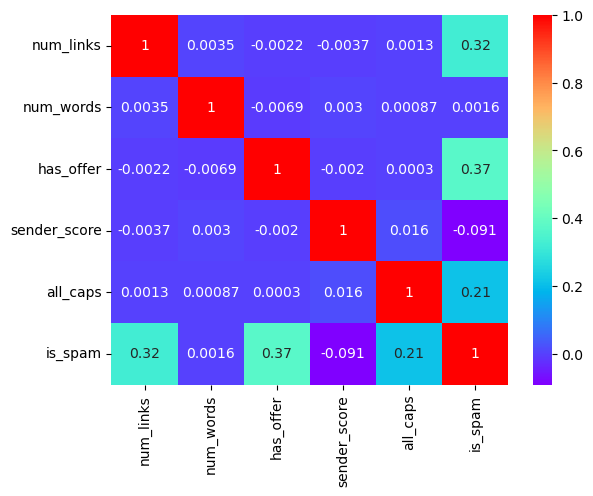

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr, annot= True, cmap="rainbow")
plt.show()

In [42]:

model= LogisticRegression()

In [44]:
model.fit(x_train, y_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [46]:
y_pred= model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(4000,))

In [52]:
model.score(x_train, y_train)

0.9413125

In [51]:
model.score(x_test, y_test)

0.94275

In [62]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.94275

In [53]:
from sklearn.metrics import confusion_matrix

In [54]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[3582,   49],
       [ 180,  189]])